In [2]:
import numpy as np
from scipy.stats import gaussian_kde
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde, rankdata
from tqdm import tqdm

In [2]:
def asymmetry_eta(x, bandwidth=None):
    """
    Estimate eta using Patil et al.-style estimator:
    eta_hat = -Corr(f_hat(X_i), F_hat(X_i))

    f_hat(X_i): leave-one-out Gaussian KDE
    F_hat(X_i): leave-one-out empirical CDF
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n < 3:
        return np.nan

    # Silverman's bandwidth
    s = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(s, iqr / 1.349) if iqr > 0 else s
    if np.isclose(sigma, 0):
        sigma = s if s > 0 else 1.0
    h = bandwidth if bandwidth is not None else 0.9 * sigma * (n ** (-1 / 5))#calculate bandwidth
    if h <= 0:
        h = 1.06 * (s if s > 0 else 1.0) * (n ** (-1 / 5))

    # Leave-one-out KDE
    diffs = (x[None, :] - x[:, None]) / h#cal culate pairwise difference
    K = stats.norm.pdf(diffs)#fit standardized distance into gaussian kernel
    np.fill_diagonal(K, 0.0)#leave one out
    f_hat = K.sum(axis=1) / ((n - 1) * h)#KED for pdf

    # Leave-one-out empirical CDF
    indicators = (x[None, :] < x[:, None]).astype(float)
    np.fill_diagonal(indicators, 0.0)
    F_hat = indicators.sum(axis=1) / (n - 1)

    if np.std(f_hat, ddof=1) == 0 or np.std(F_hat, ddof=1) == 0:
        return np.nan

    eta = -np.corrcoef(f_hat, F_hat)[0, 1]#calculate correlation

    return eta

In [5]:

def his_pdf_asymmetry_eta(x, bandwidth=None):
    """
    Estimate eta using Patil et al.-style estimator:
    eta_hat = -Corr(f_hat(X_i), F_hat(X_i))

    f_hat(X_i): leave-one-out Gaussian KDE
    F_hat(X_i): leave-one-out empirical CDF
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n < 3:
        return np.nan

    # Silverman's bandwidth
    s = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(s, iqr / 1.349) if iqr > 0 else s
    if np.isclose(sigma, 0):
        sigma = s if s > 0 else 1.0
    h = bandwidth if bandwidth is not None else 0.9 * sigma * (n ** (-1 / 5))#calculate bandwidth
    if h <= 0:
        h = 1.06 * (s if s > 0 else 1.0) * (n ** (-1 / 5))

   # Histogram-based PDF estimation
    hist, bin_edges = np.histogram(x, bins="auto", density=True)

    bin_idx = np.digitize(x, bin_edges[:-1]) - 1
    bin_idx = np.clip(bin_idx, 0, len(hist) - 1)

    f_hat = hist[bin_idx]

    # Rank-based empirical CDF
    order = np.argsort(x)
    ranks = np.empty(n, dtype=float)
    ranks[order] = np.arange(n)

    F_hat = ranks / (n - 1)


    if np.std(f_hat, ddof=1) == 0 or np.std(F_hat, ddof=1) == 0:
        return np.nan

    eta = -np.corrcoef(f_hat, F_hat)[0, 1]#calculate correlation

    return eta

In [3]:
rng = np.random.default_rng(42)
gamma_population = rng.gamma(shape=3, scale=5, size=10**8)

In [5]:
np.save("gamma_population.npy", gamma_population)

In [6]:
data = np.load("gamma_population.npy")

print(data.shape)
print(data.dtype)
print(data[:20])

(100000000,)
float64
[15.97930061 20.44729801 14.4046214  13.19662238 21.87961106 13.87977112
 17.52639368 16.57648563 21.86884783 11.88017886 26.01356464 10.13291435
 18.16897938 16.9951678   9.57296773 19.02167323 12.4244285   7.67086407
 20.36925175  5.87454458]


In [ ]:
histogram_odf_eta=his_pdf_asymmetry_eta(gamma_population)


True eta with histogram based pdf simulation method: <function his_pdf_asymmetry_eta at 0x7efdaaf165c0>


In [7]:
print("True eta with histogram based pdf simulation method:", histogram_odf_eta)

True eta with histogram based pdf simulation method: 0.5927724189553186


In [9]:
shape = 3
scale = 5

pdf_vals = stats.gamma.pdf(gamma_population, a=shape, scale=scale)
cdf_vals = stats.gamma.cdf(gamma_population, a=shape, scale=scale)

true_eta = -np.corrcoef(pdf_vals, cdf_vals)[0, 1]

print(true_eta)

0.5926011306773126


In [10]:
true_skewness = 2 / np.sqrt(3)   # Gamma(3,5)
print(true_skewness)

1.1547005383792517


In [12]:
sample_size = 10000
n_repeat = 1000

results = []

for i in tqdm(range(n_repeat)):
    sample = np.random.choice(gamma_population, size=sample_size, replace=True)
    sample_skew = stats.skew(sample, bias=False)
    sample_eta = asymmetry_eta(sample)

    diff_skew = sample_skew - true_skewness
    diff_eta = sample_eta - true_eta

    results.append({
        "iteration": i + 1,
        "sample": sample,
        "sample_skewness": sample_skew,
        "sample_eta": sample_eta,
        "diff_skewness": diff_skew,
        "diff_eta": diff_eta
    })

results_df = pd.DataFrame(results)

results_df.to_csv("gamma_stability_results.csv", index=False)

100%|██████████| 1000/1000 [30:43<00:00,  1.84s/it]


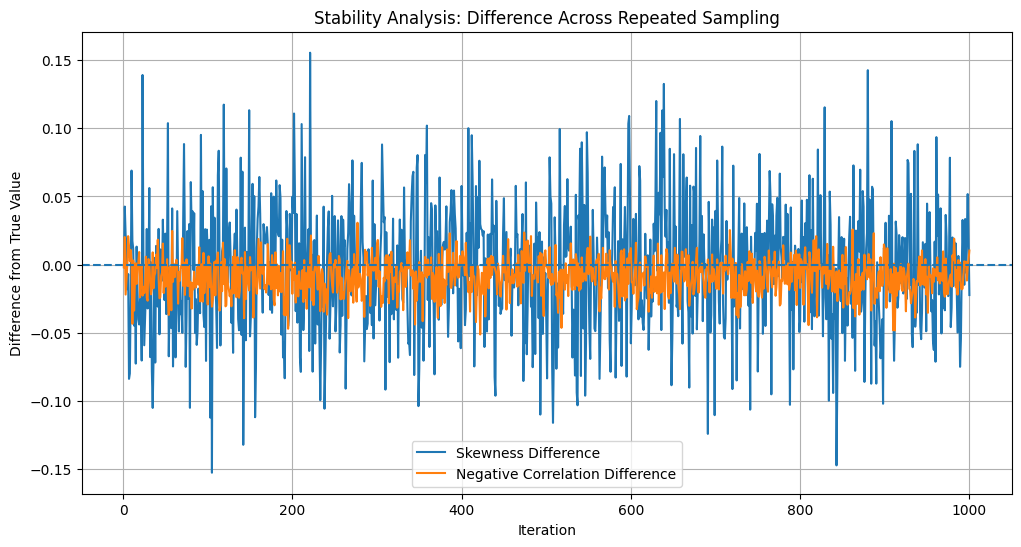

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(results_df["iteration"], results_df["diff_skewness"],
         label="Skewness Difference")

plt.plot(results_df["iteration"], results_df["diff_eta"],
         label="Negative Correlation Difference")

plt.axhline(y=0, linestyle="--")

plt.xlabel("Iteration")
plt.ylabel("Difference from True Value")
plt.title("Stability Analysis: Difference Across Repeated Sampling")
plt.legend()
plt.grid(True)

plt.show()

/tmp/ipykernel_267680/532576988.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


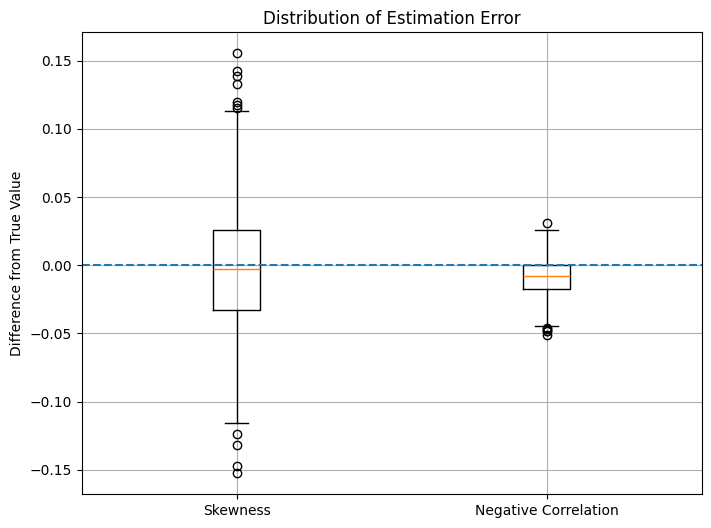

In [14]:
plt.figure(figsize=(8, 6))

plt.boxplot([
    results_df["diff_skewness"],
    results_df["diff_eta"]
], labels=["Skewness", "Negative Correlation"])

plt.axhline(y=0, linestyle="--")

plt.ylabel("Difference from True Value")
plt.title("Distribution of Estimation Error")

plt.grid(True)
plt.show()